# Sentinel-2 (L2A) AOI Ingestion — Indices Time Series (AOI-only window reads)

This notebook ingests **Sentinel‑2 L2A** imagery for a single AOI (a bounding box), computes vegetation/water indices per scene, and produces a clean time series for downstream preprocessing.

## What this notebook does
1. Define an **AOI** as a bbox in lon/lat (EPSG:4326).
2. Query the **Microsoft Planetary Computer STAC API** for Sentinel‑2 L2A scenes in a time window.
3. For each scene, read only the **AOI window** from cloud-optimized GeoTIFF (COG) assets (no full-tile downloads).
4. Use **SCL (Scene Classification Layer)** to mask clouds/shadows/no-data.
5. Compute indices (mean + p95 over valid pixels) and quality signals (valid pixel fraction).
6. Save outputs as:
   - `data/ingest/<aoi_id>/indices_timeseries.csv`
   - `data/ingest/<aoi_id>/run_metadata.json`

## Requirements
Install (one-time) in your environment (pip/uv/conda):
- `pystac-client`, `planetary-computer`, `rasterio`, `pyproj`, `python-dateutil`, `pandas`, `numpy`, `matplotlib`


## 0) Environment (optional)

If needed, install packages (choose one approach):

**pip**
```bash
pip install pystac-client planetary-computer rasterio pyproj python-dateutil pandas numpy matplotlib
```

**uv**
```bash
uv pip install pystac-client planetary-computer rasterio pyproj python-dateutil pandas numpy matplotlib
```


In [1]:
from datetime import date, datetime, timezone
from dateutil.relativedelta import relativedelta

# --------- CONFIG ---------
aoi_id = "aoi_farmtrust_demo_01"

# AOI bbox in lon/lat (EPSG:4326): [min_lon, min_lat, max_lon, max_lat]
bbox = [30.6785, 31.0472, 30.7005, 31.0612]

# Time window (recommended: start with 1 month, then expand to 24 months)
months_back = 24
end_date = date.today()
start_date = end_date - relativedelta(months=months_back)

# STAC search filters
collection = "sentinel-2-l2a"
max_cloud = 80.0          # STAC property filter (scene-level, not AOI-specific)
limit = None              # None = no hard limit; you can set e.g. 200 for quick tests

# Quality thresholds based on AOI valid pixels (after SCL mask)
usable_thresh = 0.7
excellent_thresh = 0.9

# Reflectance scaling (Sentinel-2 L2A is typically scaled by 10000)
REFLECTANCE_SCALE = 10000.0

print("AOI:", aoi_id)
print("bbox:", bbox)
print("Time window:", start_date.isoformat(), "→", end_date.isoformat())


AOI: aoi_farmtrust_demo_01
bbox: [30.6785, 31.0472, 30.7005, 31.0612]
Time window: 2024-02-10 → 2026-02-10


## 1) Imports and helpers

Key idea: the AOI bbox is in **EPSG:4326** (lon/lat degrees), while each Sentinel‑2 scene is in a projected CRS (usually **UTM**, meters).  
So we **transform the bbox to the scene CRS** before computing the raster window.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pystac_client
import planetary_computer as pc

import rasterio
from rasterio.windows import from_bounds
from rasterio.enums import Resampling
from rasterio.warp import reproject

from pyproj import Transformer
from pathlib import Path
import json


In [3]:
def sign_item_inplace(item):
    """Refresh signed URLs for an item (important for long runs)."""
    pc.sign_inplace(item)
    return item

def bbox_to_scene_crs(bbox_lonlat, dst_crs, src_crs="EPSG:4326"):
    """Transform bbox from lon/lat to scene CRS."""
    transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
    minx, miny = transformer.transform(bbox_lonlat[0], bbox_lonlat[1])
    maxx, maxy = transformer.transform(bbox_lonlat[2], bbox_lonlat[3])
    return [min(minx, maxx), min(miny, maxy), max(minx, maxx), max(miny, maxy)]

def read_bbox_window(asset_href: str, bbox_lonlat, bbox_crs="EPSG:4326", dst_resampling=Resampling.nearest):
    """Read only the AOI window from a remote COG asset."""
    with rasterio.open(asset_href) as src:
        dst_crs = src.crs
        if dst_crs is None:
            raise ValueError("Asset has no CRS; cannot compute window.")
        bbox_scene = bbox_to_scene_crs(bbox_lonlat, dst_crs.to_string(), src_crs=bbox_crs)

        # Compute pixel window from projected bounds
        window = from_bounds(*bbox_scene, transform=src.transform)

        # Clamp window to dataset bounds
        window = window.round_offsets().round_lengths()
        window = window.intersection(rasterio.windows.Window(0, 0, src.width, src.height))

        arr = src.read(1, window=window)
        transform = src.window_transform(window)
        return arr, transform, dst_crs

def resample_to_match(src_arr, src_transform, src_crs, dst_shape, dst_transform, dst_crs,
                      resampling=Resampling.nearest, dst_dtype=np.uint8):
    """Reproject/resample a source array onto a destination grid."""
    dst = np.zeros(dst_shape, dtype=dst_dtype)
    reproject(
        source=src_arr,
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=resampling,
    )
    return dst

def safe_ratio(numer, denom):
    numer = numer.astype(np.float32)
    denom = denom.astype(np.float32)
    return np.where(denom != 0, numer / denom, np.nan)

def compute_indices(red, nir, green, blue, swir1):
    """Compute indices on reflectance (0..1)."""
    # NDVI
    ndvi = safe_ratio(nir - red, nir + red)

    # EVI (expects reflectance 0..1)
    # EVI = 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    evi = 2.5 * safe_ratio((nir - red), (nir + 6*red - 7.5*blue + 1.0))

    # NDMI (NIR - SWIR1)/(NIR + SWIR1)
    ndmi = safe_ratio(nir - swir1, nir + swir1)

    # NDWI (McFeeters) (Green - NIR)/(Green + NIR)
    ndwi = safe_ratio(green - nir, green + nir)

    # MNDWI (Green - SWIR1)/(Green + SWIR1)
    mndwi = safe_ratio(green - swir1, green + swir1)

    return ndvi, evi, ndmi, ndwi, mndwi


## 2) Connect to STAC and search scenes

We search the configured time window for Sentinel‑2 L2A scenes intersecting the bbox.  
We also apply a **scene-level** cloud filter (`eo:cloud_cover`), but the AOI-specific quality is handled later by **SCL masking** + `valid_fraction`.


In [4]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,  # auto-sign items as they are read
)

dt_range = f"{start_date.isoformat()}/{end_date.isoformat()}"

search = catalog.search(
    collections=[collection],
    bbox=bbox,
    datetime=dt_range,
    query={"eo:cloud_cover": {"lt": float(max_cloud)}},
    limit=limit,
)

items = list(search.items())
items = sorted(items, key=lambda it: it.datetime)  # oldest → newest

print("Found items:", len(items))
if items:
    print("First:", items[0].datetime, items[0].id)
    print("Last :", items[-1].datetime, items[-1].id)


Found items: 186
First: 2024-02-10 08:41:11.024000+00:00 S2A_MSIL2A_20240210T084111_R064_T36RTV_20240210T141612
Last : 2026-02-04 08:40:39.024000+00:00 S2B_MSIL2A_20260204T084039_R064_T36RTV_20260204T130007


## 3) Per-scene AOI window reads + SCL mask + indices

### Why SCL?
SCL (Scene Classification Layer) labels pixels as vegetation, bare soil, water, clouds, cloud shadow, etc.

We build a **valid mask** for the AOI by excluding invalid SCL classes (clouds, shadows, no data).  
Then we compute indices only on **valid pixels** inside the AOI and summarize each scene with:
- `valid_fraction` = valid pixels / total pixels in AOI window
- mean and p95 for each index


In [5]:
# SCL classes (common):
# 0 No data, 1 Saturated/defective, 2 Dark features, 3 Cloud shadow,
# 4 Vegetation, 5 Bare soils, 6 Water,
# 7 Unclassified, 8 Cloud medium prob, 9 Cloud high prob, 10 Thin cirrus, 11 Snow

INVALID_SCL = {0, 1, 3, 7, 8, 9, 10, 11}

required_assets = ["B02", "B03", "B04", "B08", "B11", "SCL"]  # blue, green, red, nir, swir1, scl

rows = []
failed = 0

for idx, it in enumerate(items, start=1):
    try:
        sign_item_inplace(it)  # refresh signed URLs (important for long runs)

        missing = [k for k in required_assets if k not in it.assets]
        if missing:
            raise KeyError(f"Missing assets {missing} in item {it.id}")

        # Read AOI windows
        blue10, blue_tr, crs = read_bbox_window(it.assets["B02"].href, bbox)
        green10, green_tr, _ = read_bbox_window(it.assets["B03"].href, bbox)
        red10, red_tr, _     = read_bbox_window(it.assets["B04"].href, bbox)
        nir10, nir_tr, _     = read_bbox_window(it.assets["B08"].href, bbox)

        # SWIR1 (B11) is 20m, SCL is 20m → read then resample to 10m grid
        swir20, swir_tr, _   = read_bbox_window(it.assets["B11"].href, bbox)
        scl20, scl_tr, _     = read_bbox_window(it.assets["SCL"].href, bbox)

        swir10 = resample_to_match(
            swir20, swir_tr, crs,
            dst_shape=red10.shape,
            dst_transform=red_tr,
            dst_crs=crs,
            resampling=Resampling.bilinear,
            dst_dtype=np.float32,
        )

        scl10 = resample_to_match(
            scl20, scl_tr, crs,
            dst_shape=red10.shape,
            dst_transform=red_tr,
            dst_crs=crs,
            resampling=Resampling.nearest,
            dst_dtype=np.uint8,
        )

        # Convert to reflectance (0..1) where applicable
        blue = blue10.astype(np.float32) / REFLECTANCE_SCALE
        green = green10.astype(np.float32) / REFLECTANCE_SCALE
        red = red10.astype(np.float32) / REFLECTANCE_SCALE
        nir = nir10.astype(np.float32) / REFLECTANCE_SCALE
        swir1 = swir10.astype(np.float32) / REFLECTANCE_SCALE

        # Valid pixel mask from SCL
        valid = ~np.isin(scl10, list(INVALID_SCL))

        # Compute indices
        ndvi, evi, ndmi, ndwi, mndwi = compute_indices(red, nir, green, blue, swir1)

        def summarize(a):
            a_valid = np.where(valid, a, np.nan)
            if np.isfinite(a_valid).any():
                return float(np.nanmean(a_valid)), float(np.nanpercentile(a_valid, 95))
            return np.nan, np.nan

        ndvi_mean, ndvi_p95 = summarize(ndvi)
        evi_mean,  evi_p95  = summarize(evi)
        ndmi_mean, ndmi_p95 = summarize(ndmi)
        ndwi_mean, ndwi_p95 = summarize(ndwi)
        mndwi_mean, mndwi_p95 = summarize(mndwi)

        valid_fraction = float(np.sum(valid) / valid.size) if valid.size else 0.0

        rows.append({
            "item_id": it.id,
            "timestamp": it.datetime,
            "eo_cloud_cover": it.properties.get("eo:cloud_cover"),
            "mgrs_tile": it.properties.get("s2:mgrs_tile"),
            "valid_fraction": valid_fraction,

            "ndvi_mean": ndvi_mean, "ndvi_p95": ndvi_p95,
            "evi_mean": evi_mean,   "evi_p95": evi_p95,
            "ndmi_mean": ndmi_mean, "ndmi_p95": ndmi_p95,
            "ndwi_mean": ndwi_mean, "ndwi_p95": ndwi_p95,
            "mndwi_mean": mndwi_mean, "mndwi_p95": mndwi_p95,
        })

    except Exception as e:
        failed += 1
        rows.append({
            "item_id": getattr(it, "id", None),
            "timestamp": getattr(it, "datetime", None),
            "error": str(e),
        })

    if idx % 10 == 0 or idx == len(items):
        print(f"Processed {idx}/{len(items)} | failed={failed}")

df = pd.DataFrame(rows)

# Clean timestamp + sort
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.sort_values("timestamp")

print("Rows:", len(df), "| failed rows:", int(df.get("error").notna().sum()) if "error" in df.columns else 0)
df.head()


C:\Users\Sagda\AppData\Local\Temp\ipykernel_25180\4044736428.py:50: RuntimeWarning: divide by zero encountered in divide
  return np.where(denom != 0, numer / denom, np.nan)


Processed 10/186 | failed=0


C:\Users\Sagda\AppData\Local\Temp\ipykernel_25180\4044736428.py:50: RuntimeWarning: invalid value encountered in divide
  return np.where(denom != 0, numer / denom, np.nan)
C:\Users\Sagda\AppData\Local\Temp\ipykernel_25180\4044736428.py:50: RuntimeWarning: divide by zero encountered in divide
  return np.where(denom != 0, numer / denom, np.nan)
C:\Users\Sagda\AppData\Local\Temp\ipykernel_25180\4044736428.py:50: RuntimeWarning: divide by zero encountered in divide
  return np.where(denom != 0, numer / denom, np.nan)


Processed 20/186 | failed=0


C:\Users\Sagda\AppData\Local\Temp\ipykernel_25180\4044736428.py:50: RuntimeWarning: invalid value encountered in divide
  return np.where(denom != 0, numer / denom, np.nan)
C:\Users\Sagda\AppData\Local\Temp\ipykernel_25180\4044736428.py:50: RuntimeWarning: invalid value encountered in divide
  return np.where(denom != 0, numer / denom, np.nan)


...

C:\Users\Sagda\AppData\Local\Temp\ipykernel_25180\4044736428.py:50: RuntimeWarning: invalid value encountered in divide
  return np.where(denom != 0, numer / denom, np.nan)
C:\Users\Sagda\AppData\Local\Temp\ipykernel_25180\4044736428.py:50: RuntimeWarning: invalid value encountered in divide
  return np.where(denom != 0, numer / denom, np.nan)


Processed 170/186 | failed=0


C:\Users\Sagda\AppData\Local\Temp\ipykernel_25180\4044736428.py:50: RuntimeWarning: divide by zero encountered in divide
  return np.where(denom != 0, numer / denom, np.nan)
C:\Users\Sagda\AppData\Local\Temp\ipykernel_25180\4044736428.py:50: RuntimeWarning: invalid value encountered in divide
  return np.where(denom != 0, numer / denom, np.nan)
C:\Users\Sagda\AppData\Local\Temp\ipykernel_25180\4044736428.py:50: RuntimeWarning: divide by zero encountered in divide
  return np.where(denom != 0, numer / denom, np.nan)
C:\Users\Sagda\AppData\Local\Temp\ipykernel_25180\4044736428.py:50: RuntimeWarning: invalid value encountered in divide
  return np.where(denom != 0, numer / denom, np.nan)


Processed 180/186 | failed=2
Processed 186/186 | failed=8
Rows: 186 | failed rows: 8


,item_id,timestamp,eo_cloud_cover,mgrs_tile,valid_fraction,ndvi_mean,ndvi_p95,evi_mean,evi_p95,ndmi_mean,ndmi_p95,ndwi_mean,ndwi_p95,mndwi_mean,mndwi_p95,error
0,S2A_MSIL2A_20240210T084111_R064_T36RTV_2024021...,2024-02-10 08:41:11.024000+00:00,15.783826,36RTV,0.993377,0.521748,0.682675,0.600703,0.870358,0.268446,0.426607,-0.484950,-0.175700,-0.255827,-0.180363,NaN
1,S2B_MSIL2A_20240215T083939_R064_T36RTV_2024021...,2024-02-15 08:39:39.024000+00:00,53.917938,36RTV,0.971489,0.518293,0.664777,0.598924,0.854787,0.313072,0.457365,-0.473601,-0.168162,-0.193457,-0.128304,NaN
2,S2A_MSIL2A_20240220T084011_R064_T36RTV_2024022...,2024-02-20 08:40:11.024000+00:00,55.896109,36RTV,0.234431,0.465894,0.610309,0.698673,0.959450,0.253390,0.360522,-0.428255,-0.315565,-0.197925,-0.151395,NaN
3,S2B_MSIL2A_20240225T083839_R064_T36RTV_2024022...,2024-02-25 08:38:39.024000+00:00,1.468115,36RTV,0.980630,0.523980,0.686196,0.623493,0.911423,0.290327,0.455112,-0.482431,-0.175206,-0.229600,-0.141350,NaN
4,S2A_MSIL2A_20240301T083901_R064_T36RTV_2024030...,2024-03-01 08:39:01.024000+00:00,0.015090,36RTV,0.985667,0.512909,0.674118,0.588373,0.857279,0.272469,0.433057,-0.480852,-0.174211,-0.245991,-0.170779,NaN


## 4) Quality tags and quick summaries

`valid_fraction` is AOI-specific and is often a better signal than `eo:cloud_cover` for small AOIs.


In [6]:
df_ok = df[df.get("error").isna()].copy() if "error" in df.columns else df.copy()

df_ok["is_usable_scene"] = df_ok["valid_fraction"] >= float(usable_thresh)
df_ok["is_excellent_scene"] = df_ok["valid_fraction"] >= float(excellent_thresh)

print("Scenes total:", len(df_ok))
print("Usable scenes:", int(df_ok["is_usable_scene"].sum()), "/", len(df_ok))
print("Excellent scenes:", int(df_ok["is_excellent_scene"].sum()), "/", len(df_ok))

df_ok[["timestamp","item_id","eo_cloud_cover","mgrs_tile","valid_fraction","ndvi_mean","ndvi_p95"]].tail(5)


Scenes total: 178
Usable scenes: 113 / 178
Excellent scenes: 94 / 178


,timestamp,item_id,eo_cloud_cover,mgrs_tile,valid_fraction,ndvi_mean,ndvi_p95
173,2025-12-21 08:44:01.025000+00:00,S2C_MSIL2A_20251221T084401_R064_T36RTV_2025122...,0.008016,36RTV,0.993377,0.452803,0.672169
174,2025-12-23 08:45:01.024000+00:00,S2A_MSIL2A_20251223T084501_R064_T36RTV_2025122...,7.723209,36RTV,0.993377,0.450900,0.671724
175,2025-12-26 08:42:59.024000+00:00,S2B_MSIL2A_20251226T084259_R064_T36RTV_2025122...,15.747194,36RTV,0.294438,0.431866,0.647456
176,2025-12-28 08:34:01.025000+00:00,S2C_MSIL2A_20251228T083401_R021_T36RTV_2025122...,29.198968,36RTV,0.004477,0.524137,0.841209
177,2025-12-31 08:44:01.025000+00:00,S2C_MSIL2A_20251231T084401_R064_T36RTV_2025123...,0.007677,36RTV,0.993377,0.476072,0.681798


## 5) NDVI time-series plots (per scene)

We plot NDVI mean (and optionally p95). Points are individual scenes.


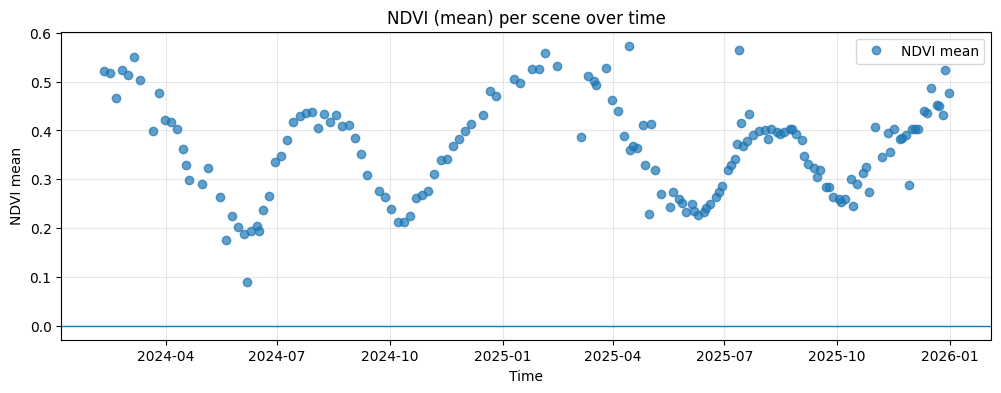

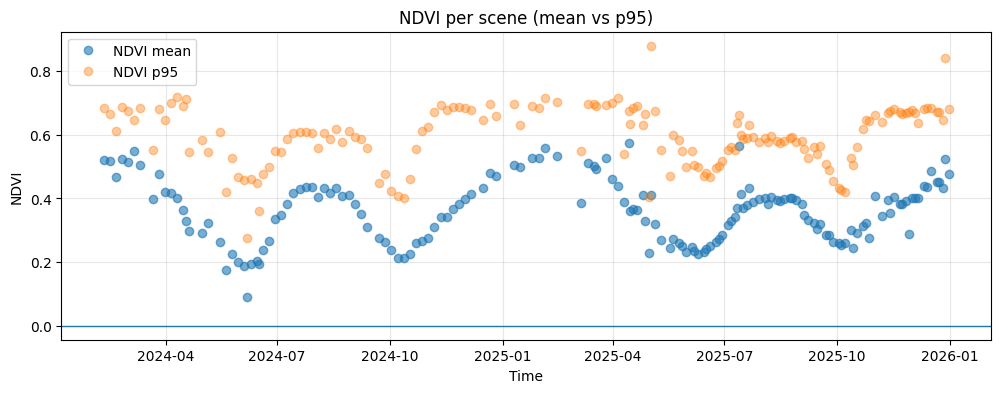

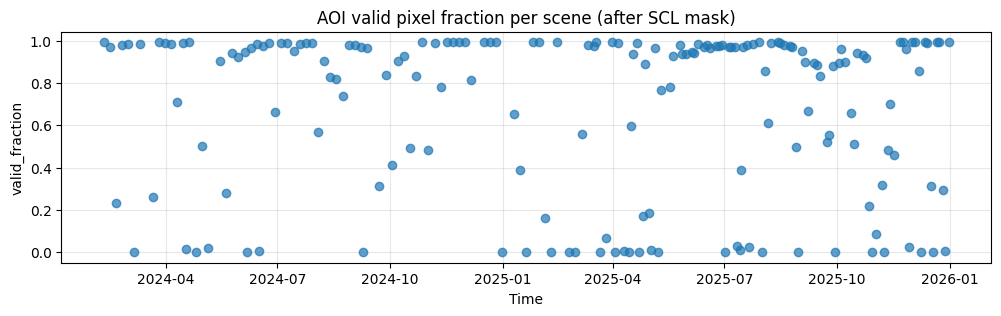

In [7]:
plt.figure(figsize=(12,4))
plt.plot(df_ok["timestamp"], df_ok["ndvi_mean"], marker="o", linestyle="None", alpha=0.7, label="NDVI mean")
plt.axhline(0, linewidth=1)
plt.title("NDVI (mean) per scene over time")
plt.xlabel("Time")
plt.ylabel("NDVI mean")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df_ok["timestamp"], df_ok["ndvi_mean"], marker="o", linestyle="None", alpha=0.6, label="NDVI mean")
plt.plot(df_ok["timestamp"], df_ok["ndvi_p95"],  marker="o", linestyle="None", alpha=0.4, label="NDVI p95")
plt.axhline(0, linewidth=1)
plt.title("NDVI per scene (mean vs p95)")
plt.xlabel("Time")
plt.ylabel("NDVI")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Optional: visualize valid_fraction over time
plt.figure(figsize=(12,3))
plt.plot(df_ok["timestamp"], df_ok["valid_fraction"], marker="o", linestyle="None", alpha=0.7)
plt.title("AOI valid pixel fraction per scene (after SCL mask)")
plt.xlabel("Time")
plt.ylabel("valid_fraction")
plt.grid(True, alpha=0.3)
plt.show()


## 6) Save outputs (CSV + metadata JSON)

This is the handoff for preprocessing: a clean per-scene time series + run metadata.


In [8]:
out_dir = Path("data/ingest") / aoi_id
out_dir.mkdir(parents=True, exist_ok=True)

# Save per-scene indices table
out_csv = out_dir / "indices_timeseries.csv"
df_ok.to_csv(out_csv, index=False)

run_meta = {
    "aoi_id": aoi_id,
    "bbox_epsg4326": bbox,
    "time_window_start": start_date.isoformat(),
    "time_window_end": end_date.isoformat(),
    "months_back": int(months_back),
    "collection": collection,
    "stac_endpoint": "https://planetarycomputer.microsoft.com/api/stac/v1",
    "eo_cloud_cover_max": float(max_cloud),
    "mask_source": "SCL",
    "invalid_scl": sorted(list(INVALID_SCL)),
    "reflectance_scale": float(REFLECTANCE_SCALE),
    "usable_thresh_valid_fraction": float(usable_thresh),
    "excellent_thresh_valid_fraction": float(excellent_thresh),
    "scenes_total": int(len(df_ok)),
    "scenes_failed": int(failed),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "notes": "AOI-only window reads from COG assets; indices computed on valid pixels after SCL mask; no full-tile downloads."
}

out_meta = out_dir / "run_metadata.json"
with open(out_meta, "w", encoding="utf-8") as f:
    json.dump(run_meta, f, ensure_ascii=False, indent=2)

print("Saved:", out_csv.resolve())
print("Saved:", out_meta.resolve())


Saved: C:\Users\Sagda\data\ingest\aoi_farmtrust_demo_01\indices_timeseries.csv
Saved: C:\Users\Sagda\data\ingest\aoi_farmtrust_demo_01\run_metadata.json


## 7) Next steps (for preprocessing)

At this point, ingestion is done. Preprocessing can:
- resample to a regular time grid (e.g., 10‑day or monthly)
- smooth (rolling median / Savitzky–Golay)
- fill short gaps (linear interpolation)
- compute confidence inputs (obs_count_usable, gap_ratio, max_gap_days, season_clarity_score)
